# Data Project

> **Note:** 
> 1. This is a starting point for how to structure your data project 
> 1. The `dataproject.py` file includes functions which can be in this notebook

In [80]:
print("n-ord")
print("n-ord")

n-ord
n-ord


Import and set magics:

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
import dataproject

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Question 1

We load the data from Danmarks Statistik, and lookup the table variables

In [82]:
from dstapi import DstApi

pris113 = DstApi('PRIS113')
print(pris113.tablesummary(language='en'))

Table PRIS113: Consumer price index by type and time
Last update: 2026-01-12T08:00:00
  variable name  # values First value     First value label Last value  \
0          TYPE         1      INDEKS  Consumer price index     INDEKS   
1           Tid       552     1980M01               1980M01    2025M12   

       Last value label  Time variable  
0  Consumer price index          False  
1               2025M12           True  


We lookup the parameter structure that 'DstApi' proposes

In [83]:
params = pris113.define_base_params(language='en')
print(params)

{'table': 'pris113', 'format': 'BULK', 'lang': 'en', 'variables': [{'code': 'TYPE', 'values': ['*']}, {'code': 'Tid', 'values': ['*']}]}


We would like to show the loaded DataFrame

In [84]:
data = pris113.get_data(params=params)
print(data.columns)
data.head()

Index(['TYPE', 'TID', 'INDHOLD'], dtype='str')


,TYPE,TID,INDHOLD
0,Consumer price index,1980M01,33.0
1,Consumer price index,1980M05,34.5
2,Consumer price index,1980M09,35.5
3,Consumer price index,1981M01,36.5
4,Consumer price index,1981M05,38.6


In [85]:
data['date'] = pd.to_datetime(data['TID'], format='%YM%m')
data = data.sort_values('date').reset_index(drop=True)
data.head()

,TYPE,TID,INDHOLD,date
0,Consumer price index,1980M01,33.0,1980-01-01
1,Consumer price index,1980M02,33.3,1980-02-01
2,Consumer price index,1980M03,33.8,1980-03-01
3,Consumer price index,1980M04,34.0,1980-04-01
4,Consumer price index,1980M05,34.5,1980-05-01


In [86]:
print(data['INDHOLD'].dtype)
print(data['INDHOLD'].head())

str
0    33.0
1    33.3
2    33.8
3    34.0
4    34.5
Name: INDHOLD, dtype: str


In [87]:
data['INDHOLD'] = data['INDHOLD'].astype(float)
print(data['INDHOLD'].dtype)
data.head()

float64


,TYPE,TID,INDHOLD,date
0,Consumer price index,1980M01,33.0,1980-01-01
1,Consumer price index,1980M02,33.3,1980-02-01
2,Consumer price index,1980M03,33.8,1980-03-01
3,Consumer price index,1980M04,34.0,1980-04-01
4,Consumer price index,1980M05,34.5,1980-05-01


In [88]:
mean_2020 = data.loc[data['date'].dt.year == 2020, 'INDHOLD'].mean()
print(mean_2020)

data['CPI_indexed'] = data['INDHOLD'] / mean_2020 * 100
data.tail()

103.43333333333334


,TYPE,TID,INDHOLD,date,CPI_indexed
547,Consumer price index,2025M08,121.7,2025-08-01,117.660329
548,Consumer price index,2025M09,121.6,2025-09-01,117.563648
549,Consumer price index,2025M10,122.1,2025-10-01,118.047051
550,Consumer price index,2025M11,121.7,2025-11-01,117.660329
551,Consumer price index,2025M12,121.2,2025-12-01,117.176926


In [89]:
data['inflation_mom'] = data['CPI_indexed'].pct_change(periods=1)
data['inflation_12m'] = data['CPI_indexed'].pct_change(periods=12)

data.tail(15)

,TYPE,TID,INDHOLD,date,CPI_indexed,inflation_mom,inflation_12m
537,Consumer price index,2024M10,119.6,2024-10-01,115.630035,0.005887,0.016143
538,Consumer price index,2024M11,119.2,2024-11-01,115.243313,-0.003344,0.016198
539,Consumer price index,2024M12,118.9,2024-12-01,114.953271,-0.002517,0.018852
540,Consumer price index,2025M01,119.6,2025-01-01,115.630035,0.005887,0.015280
541,Consumer price index,2025M02,120.8,2025-02-01,116.790203,0.010033,0.020270
542,Consumer price index,2025M03,120.2,2025-03-01,116.210119,-0.004967,0.015203
543,Consumer price index,2025M04,120.3,2025-04-01,116.306800,0.000832,0.015190
544,Consumer price index,2025M05,120.4,2025-05-01,116.403481,0.000831,0.016034
545,Consumer price index,2025M06,120.7,2025-06-01,116.693522,0.002492,0.018565
546,Consumer price index,2025M07,122.5,2025-07-01,118.433774,0.014913,0.022538


# 1.2

Text(0, 0.5, 'CPI (indeks)')

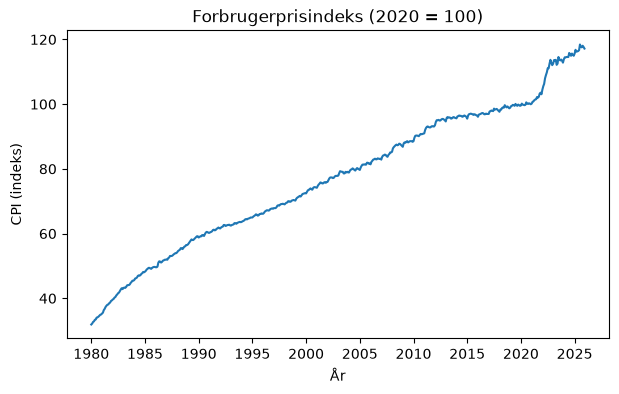

In [90]:
fig = plt.figure(figsize=(7,4))
ax = fig.add_subplot(111)

ax.plot(data['date'], data['CPI_indexed'])

ax.set_title('Forbrugerprisindeks (2020 = 100)')
ax.set_xlabel('År')
ax.set_ylabel('CPI (indeks)')

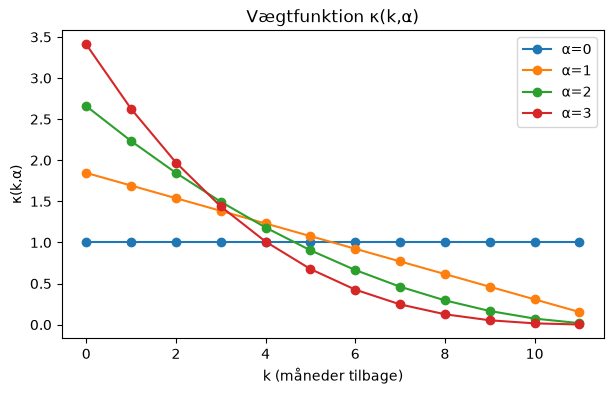

In [91]:
k_vals = np.arange(12)

fig = plt.figure(figsize=(7,4))
ax = fig.add_subplot(111)

for alpha in [0,1,2,3]:
    ax.plot(k_vals, dataproject.kappa(k_vals, alpha), marker='o', label=f'α={alpha}')

ax.set_title('Vægtfunktion κ(k,α)')
ax.set_xlabel('k (måneder tilbage)')
ax.set_ylabel('κ(k,α)')
ax.legend()

In [92]:
data = dataproject.add_instantaneous_inflation(data, alphas=[0,1,2,3])
data[['date','inflation_12m','pi_12_alpha0']].tail(10)

,date,inflation_12m,pi_12_alpha0
542,2025-03-01,0.015203,0.015203
543,2025-04-01,0.015190,0.015190
544,2025-05-01,0.016034,0.016034
545,2025-06-01,0.018565,0.018565
546,2025-07-01,0.022538,0.022538
547,2025-08-01,0.020117,0.020117
548,2025-09-01,0.022708,0.022708
549,2025-10-01,0.020903,0.020903
550,2025-11-01,0.020973,0.020973
551,2025-12-01,0.019344,0.019344


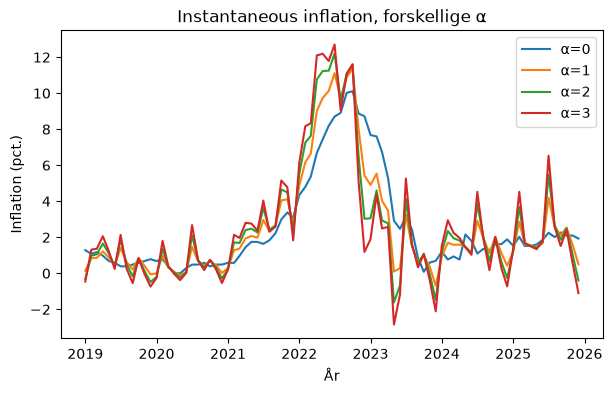

In [93]:
mask = data['date'] >= '2019-01-01'

fig = plt.figure(figsize=(7,4))
ax = fig.add_subplot(111)

for alpha in [0,1,2,3]:
    ax.plot(data.loc[mask,'date'], data.loc[mask, f'pi_12_alpha{alpha}']*100, label=f'α={alpha}')

ax.set_title('Instantaneous inflation, forskellige α')
ax.set_xlabel('År')
ax.set_ylabel('Inflation (pct.)')
ax.legend()

# 1.3

In [94]:
from dstapi import DstApi

pris111 = DstApi('PRIS111')
print(pris111.tablesummary(language='en'))

Table PRIS111: Consumer price index by commodity group, unit and time
Last update: 2026-01-12T08:00:00
  variable name  # values First value               First value label  \
0        VAREGR       385      000000  00 Consumer price index, total   
1         ENHED         3         100                           Index   
2           Tid       300     2001M01                         2001M01   

  Last value                                   Last value label  Time variable  
0     151000     15.1 Overall Consumer Price Index excl. energy          False  
1        300  Percentage change compared to same month the y...          False  
2    2025M12                                            2025M12           True  


In [95]:
print(pris111.variable_levels('ENHED', language='en'))

    id                                               text
0  100                                              Index
1  200  Percentage change compared to previous month (...
2  300  Percentage change compared to same month the y...


In [96]:
varegr_levels = pris111.variable_levels('VAREGR', language='en')
print(varegr_levels[varegr_levels['id'].isin(['000000','151000','141000'])])

         id                                               text
0    000000                     00 Consumer price index, total
383  141000  14.1 Overall Consumer Price Index - excl. ener...
384  151000     15.1 Overall Consumer Price Index excl. energy


In [97]:
data_core = dataproject.load_core_inflation_data()
print(data_core.columns)
data_core.head(6)

Index(['VAREGR', 'ENHED', 'TID', 'INDHOLD'], dtype='str')


,VAREGR,ENHED,TID,INDHOLD
0,14.1 Overall Consumer Price Index - excl. ener...,Percentage change compared to same month the y...,2006M07,1.4
1,15.1 Overall Consumer Price Index excl. energy,Percentage change compared to same month the y...,2006M07,1.5
2,"00 Consumer price index, total",Percentage change compared to same month the y...,2007M11,2.4
3,14.1 Overall Consumer Price Index - excl. ener...,Percentage change compared to same month the y...,2007M11,2.0
4,15.1 Overall Consumer Price Index excl. energy,Percentage change compared to same month the y...,2007M11,2.1
5,"00 Consumer price index, total",Percentage change compared to same month the y...,2006M07,2.0


In [98]:
data_core = dataproject.process_core_inflation_data(data_core)
data_core['VAREGR'].unique()

<ArrowStringArray>
[                                                        '00 Consumer price index, total',
 '14.1 Overall Consumer Price Index - excl. energy and unprocessed food (core inflation)',
                                         '15.1 Overall Consumer Price Index excl. energy']
Length: 3, dtype: str

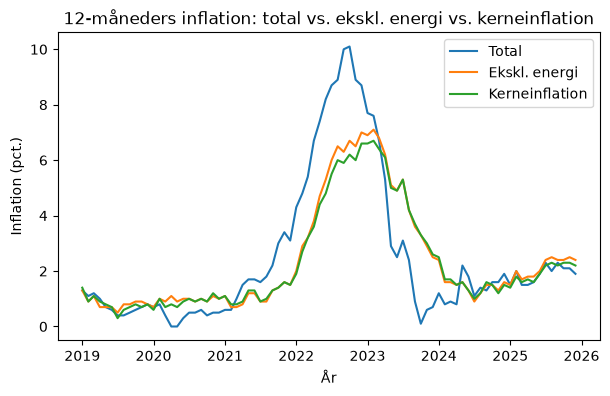

In [99]:
mask = data_core['date'] >= '2019-01-01'

fig = plt.figure(figsize=(7,4))
ax = fig.add_subplot(111)

labels = {
    '00 Consumer price index, total': 'Total',
    '15.1 Overall Consumer Price Index excl. energy': 'Ekskl. energi',
    '14.1 Overall Consumer Price Index - excl. energy and unprocessed food (core inflation)': 'Kerneinflation'
}

for varegr, label in labels.items():
    sub = data_core[(data_core['VAREGR'] == varegr) & mask]
    ax.plot(sub['date'], sub['INDHOLD'], label=label)

ax.set_title('12-måneders inflation: total vs. ekskl. energi vs. kerneinflation')
ax.set_xlabel('År')
ax.set_ylabel('Inflation (pct.)')
ax.legend()

# 1.4

In [100]:
levels = pris111.variable_levels('VAREGR', language='en')

for row in levels.itertuples():
    print(row.id, row.text)

000000 00 Consumer price index, total
010000 01 Food and non-alcoholic beverages
011000 01.1 Food
011100 01.1.1 Bread and cereals
011110 01.1.1.1 Rice
011120 01.1.1.2 Flours and other cereals
011130 01.1.1.3 Bread
011140 01.1.1.4 Other bakery products
011150 01.1.1.5 Pizza and quiche
011160 01.1.1.6 Pasta products and couscous
011170 01.1.1.7 Breakfast cereals
011180 01.1.1.8 Other cereal products
011200 01.1.2 Meat
011210 01.1.2.1 Beef and veal
011220 01.1.2.2 Pork
011230 01.1.2.3 Lamb and goat
011240 01.1.2.4 Poultry
011260 01.1.2.6 Edible offal
011270 01.1.2.7 Dried, salted or smoked meat
011280 01.1.2.8 Other meat preparations
011300 01.1.3 Fish and seafood
011310 01.1.3.1 Fresh or chilled fish
011320 01.1.3.2 Frozen fish
011340 01.1.3.4 Frozen seafood
011350 01.1.3.5 Dried, smoked or salted fish and seafood
011360 01.1.3.6 Other preserved or processed fish and seafood-based preparations
011400 01.1.4 Milk, cheese and eggs
011410 01.1.4.1 Milk, whole, fresh
011420 01.1.4.2 Milk, lo

In [101]:
pris111 = DstApi('PRIS111')
categories_4digit = dataproject.get_4digit_categories(pris111)
print(len(categories_4digit))
categories_4digit.head(10)

222


,id,text
4,011110,01.1.1.1 Rice
5,011120,01.1.1.2 Flours and other cereals
6,011130,01.1.1.3 Bread
7,011140,01.1.1.4 Other bakery products
8,011150,01.1.1.5 Pizza and quiche
9,011160,01.1.1.6 Pasta products and couscous
10,011170,01.1.1.7 Breakfast cereals
11,011180,01.1.1.8 Other cereal products
13,011210,01.1.2.1 Beef and veal
14,011220,01.1.2.2 Pork


In [102]:
data_disagg = dataproject.load_disaggregated_inflation(pris111, categories_4digit)
percentiles = dataproject.compute_percentiles(data_disagg)
percentiles.tail(10)

,date,p25,p50,p75
290,2025-03-01,-1.20,1.3,3.75
291,2025-04-01,-1.65,1.3,4.05
292,2025-05-01,-1.20,1.3,3.60
293,2025-06-01,-1.55,1.2,3.60
294,2025-07-01,-0.10,1.9,4.10
295,2025-08-01,-0.50,1.9,3.90
296,2025-09-01,-1.15,1.4,4.05
297,2025-10-01,-0.40,1.8,4.70
298,2025-11-01,-0.80,1.8,4.40
299,2025-12-01,-1.20,1.7,4.05


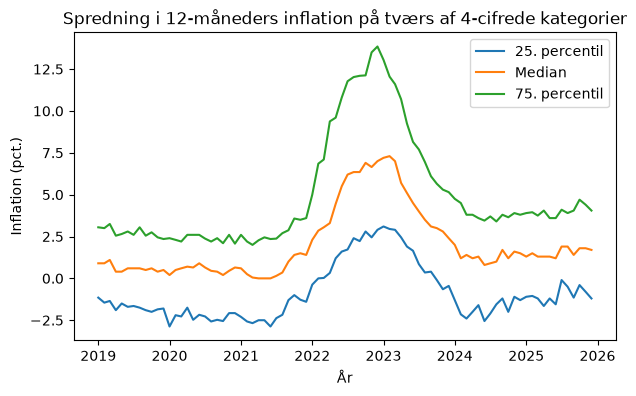

In [103]:
mask = percentiles['date'] >= '2019-01-01'

fig = plt.figure(figsize=(7,4))
ax = fig.add_subplot(111)

ax.plot(percentiles.loc[mask,'date'], percentiles.loc[mask,'p25'], label='25. percentil')
ax.plot(percentiles.loc[mask,'date'], percentiles.loc[mask,'p50'], label='Median')
ax.plot(percentiles.loc[mask,'date'], percentiles.loc[mask,'p75'], label='75. percentil')

ax.set_title('Spredning i 12-måneders inflation på tværs af 4-cifrede kategorier')
ax.set_xlabel('År')
ax.set_ylabel('Inflation (pct.)')
ax.legend()

In [105]:
data_idx = dataproject.load_disaggregated_index(pris111, categories_4digit)
pct_change_period = dataproject.compute_pct_change_period(data_idx)
pct_change_period.describe()

count    217.000000
mean      16.666301
std       17.460017
min      -22.765363
25%        6.625259
50%       16.505895
75%       26.144879
max       80.585735
Name: INDHOLD, dtype: float64

Text(0, 0.5, 'Antal kategorier')

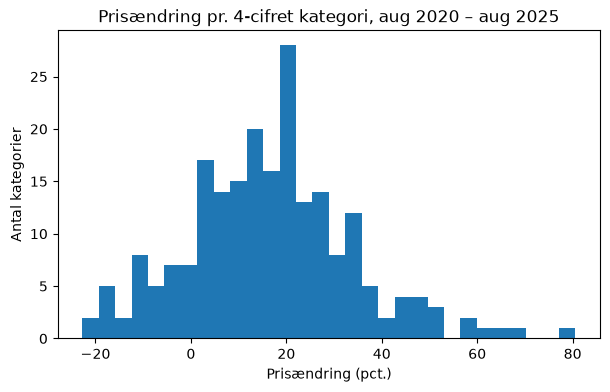

In [106]:
fig = plt.figure(figsize=(7,4))
ax = fig.add_subplot(111)

ax.hist(pct_change_period, bins=30)

ax.set_title('Prisændring pr. 4-cifret kategori, aug 2020 – aug 2025')
ax.set_xlabel('Prisændring (pct.)')
ax.set_ylabel('Antal kategorier')

In [108]:
top10, bottom10 = dataproject.top_bottom_categories(pct_change_period)
print(top10)
print(bottom10)

VAREGR
08.1.0.1 Letter handling services        80.585735
01.2.1.1 Coffee                          69.712526
02.2.0.3 Other tobacco products          65.201465
07.3.3.1 Domestic flights                62.758621
01.1.5.1 Butter                          57.085020
01.2.1.3 Cocoa and powdered chocolate    56.906615
01.1.5.4 Other edible oils               52.801724
01.1.2.1 Beef and veal                   52.736318
01.1.8.3 Chocolate                       50.844278
04.5.2.1 Natural gas and town gas        49.565217
Name: INDHOLD, dtype: float64
VAREGR
05.3.2.3 Irons                                                 -22.765363
09.1.3.1 Personal computers                                    -21.139706
05.3.2.9 Other small electric household appliances             -18.933624
09.5.1.1 Fiction books                                         -18.157895
05.3.2.4 Toasters and grills                                   -17.723881
05.3.2.1 Food processing appliances                            -17.634855
05

In [ ]:
data = dataproject.load_data()

## Question 2

We process the data by ...

In [ ]:
data = dataproject.process_data(data)

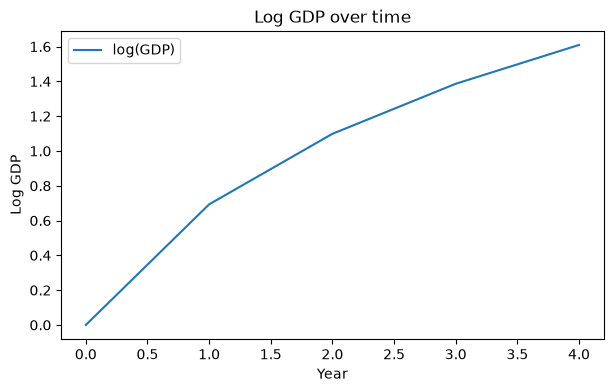

In [ ]:
fig = plt.figure(figsize=(7,4))
ax = fig.add_subplot(111)

ax.plot(data['log_GDP'],label='log(GDP)')

ax.set_title('Log GDP over time')
ax.set_xlabel('Year')
ax.set_ylabel('Log GDP')

ax.legend();

We find that that ...

Lookup table variables